In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

sys.path.insert(0, str(ROOT))

from src.data import BUSIDataset, discover_busi_samples
from src.reproducibility import seed_everything

seed_everything(42)

DATA_ROOT = ROOT / "data" / "raw" / "BUSI" / "BUSI"

print("Project root:", ROOT)
print("Dataset root:", DATA_ROOT)
print("Dataset exists:", DATA_ROOT.exists())
print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)

Project root: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab
Dataset root: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\data\raw\BUSI\BUSI
Dataset exists: True
Python executable: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cpu


In [2]:
from collections import Counter

samples = discover_busi_samples(DATA_ROOT)

class_counts = Counter(
    sample.class_name
    for sample in samples
)

dataset = BUSIDataset(
    samples=samples,
    image_size=128,
)

print("Total samples:", len(samples))
print("Class counts:", dict(class_counts))
print("Dataset length:", len(dataset))

Total samples: 629
Class counts: {'benign': 420, 'malignant': 209}
Dataset length: 629


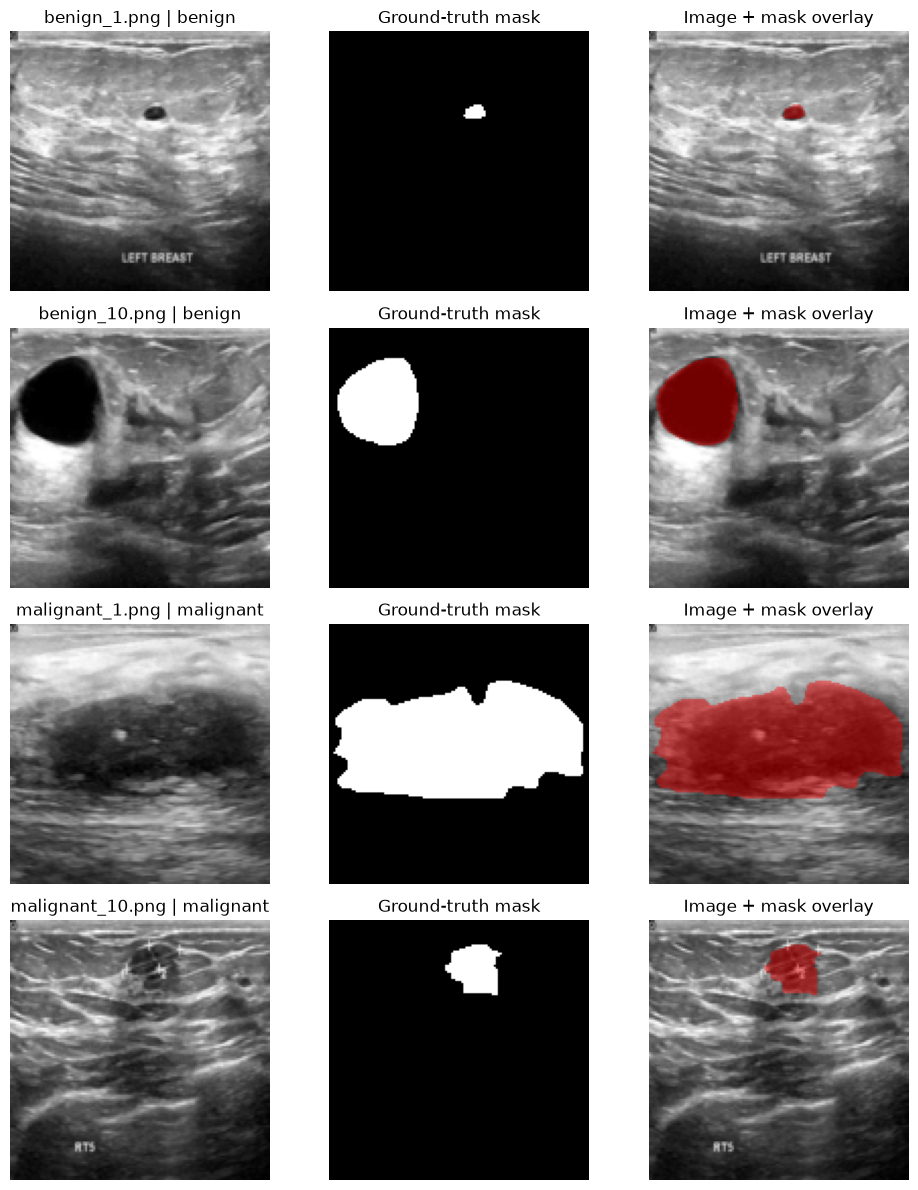

In [3]:
selected_indices = []

for class_name in ("benign", "malignant"):
    class_indices = [
        index
        for index, sample in enumerate(samples)
        if sample.class_name == class_name
    ]

    selected_indices.extend(class_indices[:2])


fig, axes = plt.subplots(
    nrows=len(selected_indices),
    ncols=3,
    figsize=(10, 12),
)

for row, index in enumerate(selected_indices):
    item = dataset[index]

    image = item["image"].squeeze(0).numpy()
    mask = item["mask"].squeeze(0).numpy()

    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title(
        f"{item['filename']} | {item['class_name']}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground-truth mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(image, cmap="gray")
    axes[row, 2].imshow(
        np.ma.masked_where(mask == 0, mask),
        cmap="autumn",
        alpha=0.45,
    )
    axes[row, 2].set_title("Image + mask overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
from collections import defaultdict

lesion_fractions = defaultdict(list)

for item in dataset:
    class_name = item["class_name"]
    lesion_fraction = item["mask"].mean().item()

    lesion_fractions[class_name].append(
        lesion_fraction
    )

for class_name, values in lesion_fractions.items():
    values = np.asarray(values)

    print(f"\nClass: {class_name}")
    print("Samples:", len(values))
    print("Minimum lesion fraction:", values.min())
    print("Median lesion fraction:", np.median(values))
    print("Mean lesion fraction:", values.mean())
    print("Maximum lesion fraction:", values.max())


Class: benign
Samples: 420
Minimum lesion fraction: 0.002685546875
Median lesion fraction: 0.03790283203125
Mean lesion fraction: 0.06710306803385417
Maximum lesion fraction: 0.4625244140625

Class: malignant
Samples: 209
Minimum lesion fraction: 0.0050048828125
Median lesion fraction: 0.1212158203125
Mean lesion fraction: 0.1478338652250299
Maximum lesion fraction: 0.56243896484375


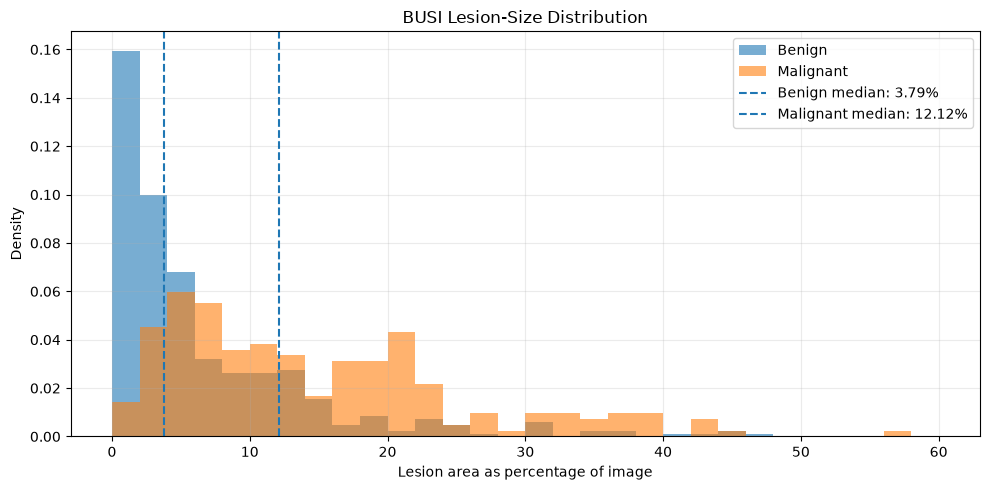

Saved figure: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\reports\figures\busi_lesion_fraction_distribution.png


In [5]:
benign_percent = (
    np.asarray(lesion_fractions["benign"]) * 100
)

malignant_percent = (
    np.asarray(lesion_fractions["malignant"]) * 100
)

bins = np.linspace(0, 60, 31)

plt.figure(figsize=(10, 5))

plt.hist(
    benign_percent,
    bins=bins,
    alpha=0.6,
    density=True,
    label="Benign",
)

plt.hist(
    malignant_percent,
    bins=bins,
    alpha=0.6,
    density=True,
    label="Malignant",
)

plt.axvline(
    np.median(benign_percent),
    linestyle="--",
    label=(
        "Benign median: "
        f"{np.median(benign_percent):.2f}%"
    ),
)

plt.axvline(
    np.median(malignant_percent),
    linestyle="--",
    label=(
        "Malignant median: "
        f"{np.median(malignant_percent):.2f}%"
    ),
)

plt.xlabel("Lesion area as percentage of image")
plt.ylabel("Density")
plt.title("BUSI Lesion-Size Distribution")
plt.legend()
plt.grid(alpha=0.25)

figure_path = (
    ROOT
    / "reports"
    / "figures"
    / "busi_lesion_fraction_distribution.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", figure_path)

In [6]:
from collections import defaultdict
import hashlib

from PIL import Image


def calculate_pixel_hash(image_path):
    """Calculate a hash from image dimensions and pixel values."""

    with Image.open(image_path) as image:
        image_array = np.asarray(
            image.convert("L"),
            dtype=np.uint8,
        )

    hash_generator = hashlib.sha256()

    hash_generator.update(
        str(image_array.shape).encode("utf-8")
    )

    hash_generator.update(
        image_array.tobytes()
    )

    return hash_generator.hexdigest()


image_hash_groups = defaultdict(list)

for sample in samples:
    image_hash = calculate_pixel_hash(
        sample.image_path
    )

    image_hash_groups[image_hash].append(
        sample
    )


duplicate_groups = [
    group
    for group in image_hash_groups.values()
    if len(group) > 1
]

duplicate_sample_count = sum(
    len(group)
    for group in duplicate_groups
)

print(
    "Unique image hashes:",
    len(image_hash_groups),
)

print(
    "Duplicate groups:",
    len(duplicate_groups),
)

print(
    "Samples inside duplicate groups:",
    duplicate_sample_count,
)


for group_number, group in enumerate(
    duplicate_groups[:10],
    start=1,
):
    filenames = [
        sample.image_path.name
        for sample in group
    ]

    classes = [
        sample.class_name
        for sample in group
    ]

    mask_hashes = {
        calculate_pixel_hash(sample.mask_path)
        for sample in group
    }

    print(f"\nDuplicate group {group_number}:")
    print("Files:", filenames)
    print("Classes:", classes)
    print("Unique masks:", len(mask_hashes))

Unique image hashes: 628
Duplicate groups: 1
Samples inside duplicate groups: 2

Duplicate group 1:
Files: ['benign_433.png', 'malignant_145.png']
Classes: ['benign', 'malignant']
Unique masks: 2


File A: benign_433.png
Class A: benign
Mask A pixels: 3186

File B: malignant_145.png
Class B: malignant
Mask B pixels: 4112

Images exactly identical: True
Mask Dice: 0.8731159221704576
Mask IoU: 0.7748054474708171


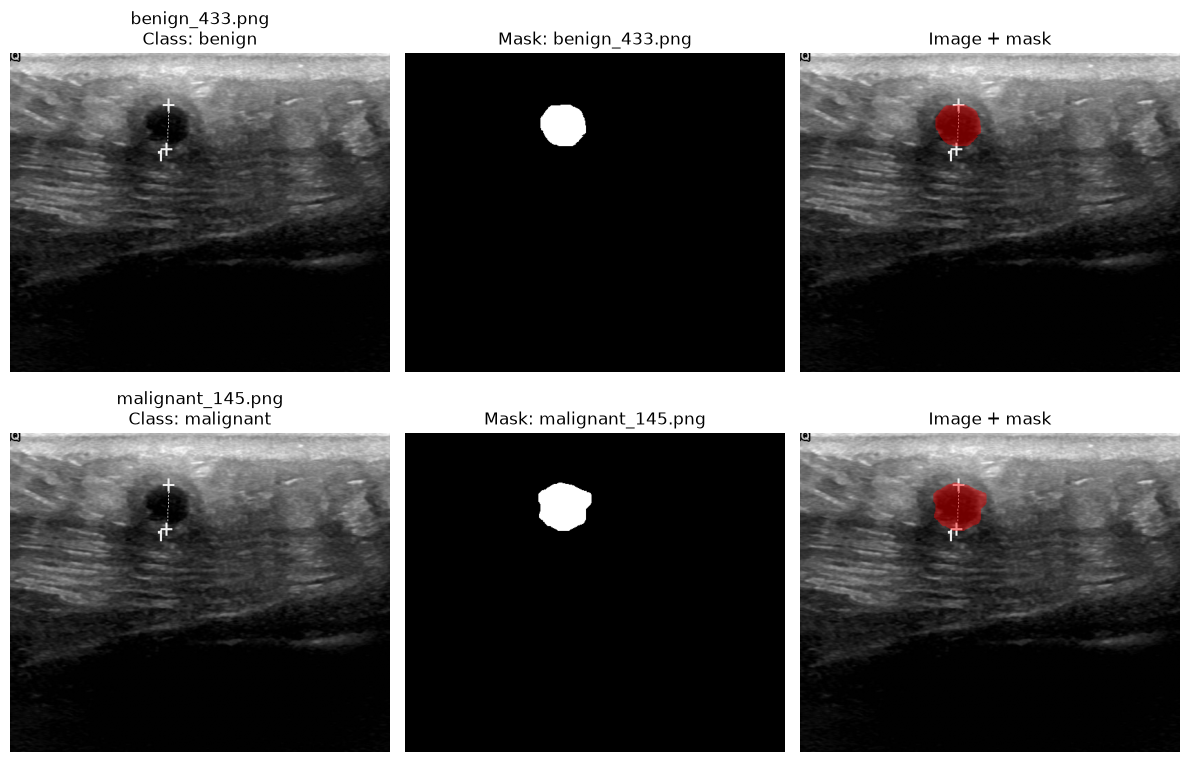

In [7]:
duplicate_group = duplicate_groups[0]

sample_a = duplicate_group[0]
sample_b = duplicate_group[1]


with Image.open(sample_a.image_path) as image:
    image_a = np.asarray(
        image.convert("L"),
        dtype=np.uint8,
    )

with Image.open(sample_b.image_path) as image:
    image_b = np.asarray(
        image.convert("L"),
        dtype=np.uint8,
    )

with Image.open(sample_a.mask_path) as mask:
    mask_a = np.asarray(
        mask.convert("L"),
    ) > 0

with Image.open(sample_b.mask_path) as mask:
    mask_b = np.asarray(
        mask.convert("L"),
    ) > 0


intersection = np.logical_and(
    mask_a,
    mask_b,
).sum()

union = np.logical_or(
    mask_a,
    mask_b,
).sum()

dice = (
    2 * intersection
    / (mask_a.sum() + mask_b.sum())
)

iou = intersection / union


print("File A:", sample_a.image_path.name)
print("Class A:", sample_a.class_name)
print("Mask A pixels:", mask_a.sum())

print()

print("File B:", sample_b.image_path.name)
print("Class B:", sample_b.class_name)
print("Mask B pixels:", mask_b.sum())

print()

print(
    "Images exactly identical:",
    np.array_equal(image_a, image_b),
)

print("Mask Dice:", dice)
print("Mask IoU:", iou)


fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 8),
)

items = [
    (
        image_a,
        mask_a,
        sample_a,
    ),
    (
        image_b,
        mask_b,
        sample_b,
    ),
]

for row, (image, mask, sample) in enumerate(items):
    axes[row, 0].imshow(
        image,
        cmap="gray",
    )
    axes[row, 0].set_title(
        f"{sample.image_path.name}\n"
        f"Class: {sample.class_name}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        mask,
        cmap="gray",
    )
    axes[row, 1].set_title(
        f"Mask: {sample.mask_path.name}"
    )
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        image,
        cmap="gray",
    )
    axes[row, 2].imshow(
        np.ma.masked_where(
            mask == 0,
            mask,
        ),
        cmap="autumn",
        alpha=0.45,
    )
    axes[row, 2].set_title(
        "Image + mask"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
EXCLUDED_FILENAMES = {
    "benign_433.png",
    "malignant_145.png",
}

clean_samples = [
    sample
    for sample in samples
    if sample.image_path.name
    not in EXCLUDED_FILENAMES
]

clean_class_counts = Counter(
    sample.class_name
    for sample in clean_samples
)

print("Original samples:", len(samples))
print("Excluded samples:", len(samples) - len(clean_samples))
print("Clean samples:", len(clean_samples))
print("Clean class counts:", dict(clean_class_counts))

Original samples: 629
Excluded samples: 2
Clean samples: 627
Clean class counts: {'benign': 419, 'malignant': 208}


In [9]:
from sklearn.model_selection import train_test_split


class_labels = [
    sample.class_name
    for sample in clean_samples
]


train_samples, temporary_samples = train_test_split(
    clean_samples,
    test_size=0.30,
    random_state=42,
    stratify=class_labels,
)


temporary_labels = [
    sample.class_name
    for sample in temporary_samples
]


val_samples, test_samples = train_test_split(
    temporary_samples,
    test_size=0.50,
    random_state=42,
    stratify=temporary_labels,
)


def summarize_split(split_name, split_samples):
    class_counts = Counter(
        sample.class_name
        for sample in split_samples
    )

    print(f"\n{split_name}")
    print("Samples:", len(split_samples))
    print("Class counts:", dict(class_counts))


summarize_split("Train", train_samples)
summarize_split("Validation", val_samples)
summarize_split("Test", test_samples)


Train
Samples: 438
Class counts: {'malignant': 145, 'benign': 293}

Validation
Samples: 94
Class counts: {'malignant': 31, 'benign': 63}

Test
Samples: 95
Class counts: {'benign': 63, 'malignant': 32}


In [10]:
def filename_set(split_samples):
    return {
        sample.image_path.name
        for sample in split_samples
    }


def image_hash_set(split_samples):
    return {
        calculate_pixel_hash(sample.image_path)
        for sample in split_samples
    }


train_names = filename_set(train_samples)
val_names = filename_set(val_samples)
test_names = filename_set(test_samples)

train_hashes = image_hash_set(train_samples)
val_hashes = image_hash_set(val_samples)
test_hashes = image_hash_set(test_samples)


print("Filename overlap")
print(
    "Train / Validation:",
    len(train_names & val_names),
)
print(
    "Train / Test:",
    len(train_names & test_names),
)
print(
    "Validation / Test:",
    len(val_names & test_names),
)


print("\nPixel-hash overlap")
print(
    "Train / Validation:",
    len(train_hashes & val_hashes),
)
print(
    "Train / Test:",
    len(train_hashes & test_hashes),
)
print(
    "Validation / Test:",
    len(val_hashes & test_hashes),
)


assert not train_names & val_names
assert not train_names & test_names
assert not val_names & test_names

assert not train_hashes & val_hashes
assert not train_hashes & test_hashes
assert not val_hashes & test_hashes

assert (
    len(train_samples)
    + len(val_samples)
    + len(test_samples)
    == len(clean_samples)
)

print("\nSplit leakage check: PASSED")

Filename overlap
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

Pixel-hash overlap
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

Split leakage check: PASSED


In [11]:
import pandas as pd


split_by_filename = {}

for split_name, split_samples in (
    ("train", train_samples),
    ("validation", val_samples),
    ("test", test_samples),
):
    for sample in split_samples:
        split_by_filename[
            sample.image_path.name
        ] = split_name


manifest_rows = []

for sample in sorted(
    samples,
    key=lambda item: item.image_path.name,
):
    filename = sample.image_path.name

    if filename in EXCLUDED_FILENAMES:
        split_name = "excluded"
        exclusion_reason = (
            "Conflicting duplicate image and class annotation"
        )
    else:
        split_name = split_by_filename[filename]
        exclusion_reason = ""

    manifest_rows.append(
        {
            "filename": filename,
            "class_name": sample.class_name,
            "split": split_name,
            "image_sha256": calculate_pixel_hash(
                sample.image_path
            ),
            "exclusion_reason": exclusion_reason,
        }
    )


split_manifest = pd.DataFrame(manifest_rows)

manifest_path = (
    ROOT
    / "data"
    / "splits"
    / "busi_seed42.csv"
)

manifest_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

split_manifest.to_csv(
    manifest_path,
    index=False,
)


print("Manifest rows:", len(split_manifest))

print(
    "\nSplit counts:"
)

print(
    split_manifest["split"]
    .value_counts()
    .sort_index()
)

print(
    "\nClass counts by split:"
)

print(
    pd.crosstab(
        split_manifest["split"],
        split_manifest["class_name"],
    )
)

print("\nSaved manifest:", manifest_path)

Manifest rows: 629

Split counts:
split
excluded        2
test           95
train         438
validation     94
Name: count, dtype: int64

Class counts by split:
class_name  benign  malignant
split                        
excluded         1          1
test            63         32
train          293        145
validation      63         31

Saved manifest: c:\Users\SETUP CO\article28-unet-projects\unet-medical-reliability-lab\data\splits\busi_seed42.csv


In [12]:
loaded_manifest = pd.read_csv(manifest_path)

expected_split_counts = {
    "train": 438,
    "validation": 94,
    "test": 95,
    "excluded": 2,
}

dataset_filenames = {
    sample.image_path.name
    for sample in samples
}

manifest_filenames = set(
    loaded_manifest["filename"]
)

actual_split_counts = (
    loaded_manifest["split"]
    .value_counts()
    .to_dict()
)


assert len(loaded_manifest) == 629

assert loaded_manifest["filename"].is_unique

assert manifest_filenames == dataset_filenames

assert actual_split_counts == expected_split_counts

assert loaded_manifest[
    "image_sha256"
].notna().all()

active_manifest = loaded_manifest[
    loaded_manifest["split"] != "excluded"
]

assert len(active_manifest) == 627

assert active_manifest[
    "image_sha256"
].is_unique


print("Manifest rows:", len(loaded_manifest))
print("Unique filenames:", loaded_manifest["filename"].nunique())
print("Active samples:", len(active_manifest))
print("Active image hashes:", active_manifest["image_sha256"].nunique())
print("Split counts:", actual_split_counts)
print("Manifest validation: PASSED")

Manifest rows: 629
Unique filenames: 629
Active samples: 627
Active image hashes: 627
Split counts: {'train': 438, 'test': 95, 'validation': 94, 'excluded': 2}
Manifest validation: PASSED
